# Análisis estratégico y clustering de cartas: Wingspan

**Proyecto final — Diplomado en Transformación Digital Empresarial**  
**Autora:** Marcela Cadena  
**Fecha:** Junio 2026

---

## Pregunta de investigación

> ¿Qué grupos naturales emergen de los textos de poder de las cartas de Wingspan, y cómo se relacionan esos grupos con el tipo de activación, las mecánicas especiales y el hábitat del ave?

**Motivación estratégica:** Cada carta de Wingspan tiene un poder descrito en texto libre. Ese texto contiene la esencia estratégica de la carta: qué hace, cuándo lo hace y qué recursos mueve. Si agrupamos las cartas según la similitud de sus poderes, podemos descubrir patrones que las reglas del juego no explicitan — y usarlos para tomar mejores decisiones en el *draft* inicial.

---

**Estructura del notebook:**
1. Problema y datos (15%)
2. Modelado y análisis (35%)
3. Interpretación de clusters (25%)
4. Conclusiones (15%)
5. Uso de IA (10%)

---
## 1. Problema y datos
### 1.1 Carga de datos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'wingspan-20260128.xlsx')

# Las filas 1 y 2 del Excel contienen estadísticas internas, no cartas.
df_raw = pd.read_excel(DATA_PATH, sheet_name='Birds', skiprows=[1, 2])

print(f'Dimensiones del dataset: {df_raw.shape}')
df_raw.head(3)

Dimensiones del dataset: (707, 65)


,Common name,Scientific name,Set,Color,Power text,Predator,Flocking,Bonus card,Victory points,Nest type,...,Nest Box Builder,Omnivore Expert,Passerine Specialist,Platform Builder,Prairie Manager,Rodentologist,Small Clutch Specialist,Viticulturalist,Wetland Scientist,Wildlife Gardener
0,Abbott's Booby,Papasula abbotti,oceania,white,"Draw 3 bonus cards, then discard 2. You may di...",NaN,NaN,X,5,platform,...,NaN,NaN,NaN,X,NaN,NaN,X,NaN,X,NaN
1,Acadian Flycatcher,Empidonax virescens,promoUS,brown,Draw and discard 1 [card] from the deck. If it...,NaN,NaN,NaN,2,wild,...,X,NaN,X,X,NaN,NaN,X,NaN,NaN,X
2,Acorn Woodpecker,Melanerpes formicivorus,core,brown,"Gain 1 [seed] from the birdfeeder, if availabl...",NaN,NaN,NaN,5,cavity,...,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Exploración del campo `Power text`

In [11]:
# Eliminar filas sin nombre de ave
df = df_raw.dropna(subset=['Common name']).reset_index(drop=True)
print(f'Total de cartas: {len(df)}')

# Cartas con y sin poder
con_poder = df['Power text'].notna().sum()
sin_poder = df['Power text'].isna().sum()
print(f'Cartas con Power text:  {con_poder} ({con_poder/len(df)*100:.1f}%)')
print(f'Cartas sin Power text:  {sin_poder} ({sin_poder/len(df)*100:.1f}%)')

Total de cartas: 707
Cartas con Power text:  701 (99.2%)
Cartas sin Power text:  6 (0.8%)


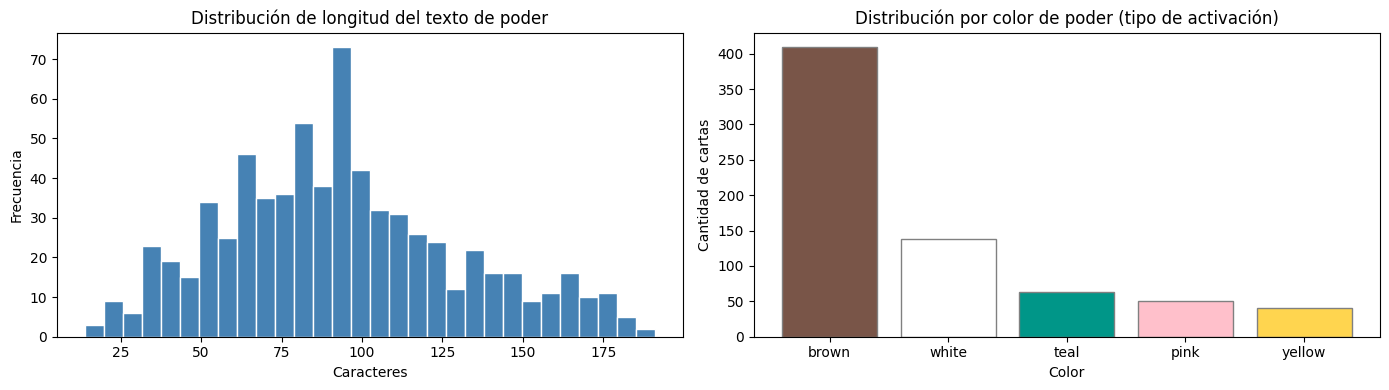

In [15]:
# Longitud del texto de poder
df['power_length'] = df['Power text'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['power_length'] > 0]['power_length'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud del texto de poder')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

color_counts = df['Color'].value_counts()
axes[1].bar(color_counts.index, color_counts.values,
            color=['#795548', '#FFFFFF', '#009688', '#FFC0CB', '#FFD54F'],
            edgecolor='gray')
axes[1].set_title('Distribución por color de poder (tipo de activación)')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Cantidad de cartas')

plt.tight_layout()
plt.show()

In [19]:
# Resumen: distribución por color en cada Set
from IPython.display import display

counts = df.groupby(['Set', 'Color']).size().unstack(fill_value=0)
counts['Total'] = counts.sum(axis=1)

pct = counts.div(counts['Total'], axis=0).multiply(100).round(1)

color_cols = [c for c in counts.columns if c != 'Total']
formatted = counts[color_cols].astype(str) + ' (' + pct[color_cols].astype(str) + '%)'
formatted['Total'] = counts['Total']

formatted = formatted.sort_values('Total', ascending=False)

# Quitar el título "Color" que aparece sobre las columnas
formatted.columns.name = None

print("Distribución por Color dentro de cada Set (conteo (porcentaje%))\n")
display(formatted.reset_index())


Distribución por Color dentro de cada Set (conteo (porcentaje%))



,Set,brown,pink,teal,white,yellow,Total
0,core,125 (71.8%),12 (6.9%),0 (0.0%),37 (21.3%),0 (0.0%),174
1,americas,67 (60.4%),11 (9.9%),12 (10.8%),16 (14.4%),5 (4.5%),111
2,oceania,59 (62.1%),5 (5.3%),0 (0.0%),15 (15.8%),16 (16.8%),95
3,asia,54 (60.0%),2 (2.2%),16 (17.8%),15 (16.7%),3 (3.3%),90
4,european,38 (46.9%),5 (6.2%),20 (24.7%),18 (22.2%),0 (0.0%),81
5,promoAsia,12 (48.0%),2 (8.0%),2 (8.0%),6 (24.0%),3 (12.0%),25
6,promoCA,12 (48.0%),2 (8.0%),3 (12.0%),6 (24.0%),2 (8.0%),25
7,promoEurope,11 (44.0%),3 (12.0%),3 (12.0%),5 (20.0%),3 (12.0%),25
8,promoNZ,11 (44.0%),2 (8.0%),1 (4.0%),9 (36.0%),2 (8.0%),25
9,promoUK,8 (32.0%),4 (16.0%),4 (16.0%),5 (20.0%),4 (16.0%),25


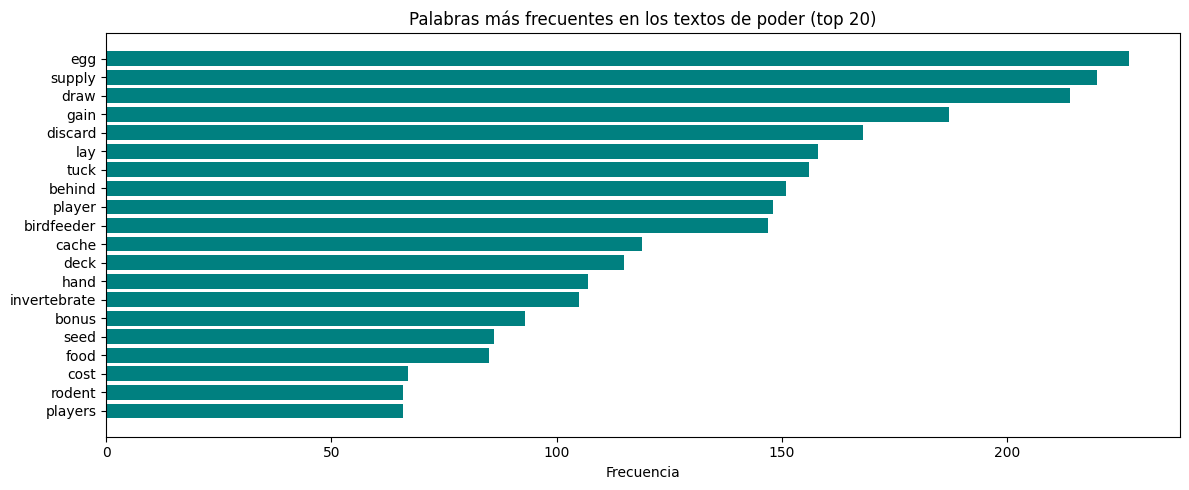

In [20]:
# Palabras más frecuentes en los textos de poder
from collections import Counter

# Palabras vacías a ignorar (stop words del dominio)
stop_words = {
    'the', 'a', 'an', 'this', 'that', 'of', 'in', 'on', 'to', 'from',
    'for', 'with', 'or', 'and', 'if', 'you', 'your', 'may', 'can',
    'bird', 'birds', 'card', 'cards', 'all', 'any', 'each', 'is', 'it',
    'its', 'at', 'than', 'then', 'when', 'do', 'not', 'has', 'have',
    'no', 'are', 'be', 'as', 'up', 'per', 'turn', 'other', 'another'
}

all_words = []
for text in df['Power text'].dropna():
    words = re.findall(r'[a-z]+', text.lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

top_words = Counter(all_words).most_common(20)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(list(reversed(words)), list(reversed(counts)), color='teal')
ax.set_title('Palabras más frecuentes en los textos de poder (top 20)')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

**Interpretación:** Las palabras más frecuentes revelan las mecánicas dominantes del juego: `egg`, `draw`, `food`, `cache`, `lay`, `tuck`. Estas son exactamente las acciones que definen los tres motores principales. La distribución de longitud del texto muestra que la mayoría de los poderes son descripciones cortas (menos de 150 caracteres), lo que sugiere vocabulario repetido y patrones claros para el clustering.

### 1.3 Limpieza y preparación del texto

In [14]:
def clean_power_text(text):
    if pd.isna(text):
        return ''
    # Minúsculas
    text = text.lower()
    # Reemplazar símbolos de recursos del juego por palabras legibles
    text = re.sub(r'\[invertebrate\]', 'invertebrate', text)
    text = re.sub(r'\[seed\]', 'seed', text)
    text = re.sub(r'\[fish\]', 'fish', text)
    text = re.sub(r'\[fruit\]', 'fruit', text)
    text = re.sub(r'\[rodent\]', 'rodent', text)
    text = re.sub(r'\[nectar\]', 'nectar', text)
    text = re.sub(r'\[wild\]', 'wild', text)
    text = re.sub(r'\[egg\]', 'egg', text)
    text = re.sub(r'\[card\]', 'card', text)
    # Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['power_clean'] = df['Power text'].apply(clean_power_text)

# Separar cartas con y sin poder para el análisis
df_con_poder = df[df['power_clean'] != ''].reset_index(drop=True)
df_sin_poder = df[df['power_clean'] == ''].reset_index(drop=True)

print(f'Cartas con poder (entran al clustering): {len(df_con_poder)}')
print(f'Cartas sin poder (excluidas del clustering): {len(df_sin_poder)}')
print(f'\nEjemplo de texto limpio:')
print(df_con_poder[['Common name', 'Power text', 'power_clean']].head(3).to_string())

Cartas con poder (entran al clustering): 701
Cartas sin poder (excluidas del clustering): 6

Ejemplo de texto limpio:
          Common name                                                                                                                                                                          Power text                                                                                                                                                        power_clean
0      Abbott's Booby                                                                                         Draw 3 bonus cards, then discard 2. You may discard bonus cards you did not draw this turn.                                                                               draw bonus cards then discard you may discard bonus cards you did not draw this turn
1  Acadian Flycatcher  Draw and discard 1 [card] from the deck. If it has [invertebrate] in its food cost, gain 1 [invertebrate] from the supply and cac

**Nota:** Las cartas sin poder son aves con valor puramente estático (solo suman puntos base al final). Se excluyen del clustering porque no aportan información textual, pero se analizan como grupo separado en la sección de interpretación.

---
## 2. Modelado y análisis

*Esta sección se completa en el siguiente commit.*

---
## 3. Interpretación de clusters

*Esta sección se completa en el siguiente commit.*

---
## 4. Conclusiones

*Esta sección se completa en el siguiente commit.*

---
## 5. Uso de IA

*Esta sección se completa en el siguiente commit.*